(1, 501)


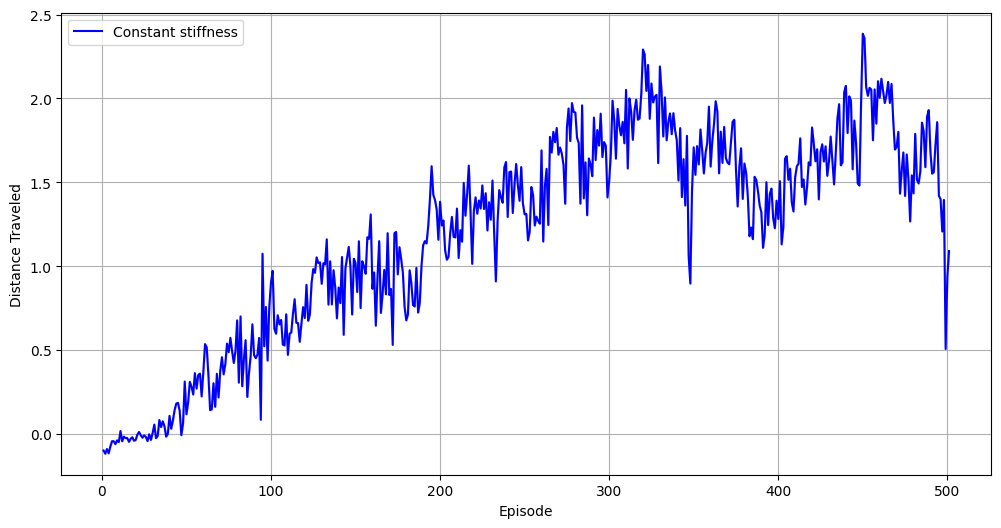

In [1]:
# Load all distance histories for both groups
#C:\Users\User\Desktop\New folder\data\Exponential\distance\distance_history_seed_1.npy



# des = 'LegEnv_Jul04_constant_100k_lr_5e-04_PPO_new_reward_joint_damping'
des = 'Dynamic-tendon-Leg\JJ\data\LegEnv_Jul22_constant_5k_lr_5e-04_PPO' #'data/LegEnv_Jul22_constant_5k_lr_5e-04_PPO'
# C:\Users\User\Desktop\Dynamic-tendon-Leg\Dynamic-tendon-Leg\JJ\data\LegEnv_Jul22_constant_5k_lr_5e-04_PPO\displacements\displacements_seed_100.npy
import numpy as np
import matplotlib.pyplot as plt
# dist_file = [fr'C:\Users\User\Desktop\Dynamic-tendon-Leg\{des}\displacements\displacements_seed_{seed_value}.npy' for seed_value in range(100, 101)]  # Adjust filenames if necessary
dist_file= [fr"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Jul20_constant_20k_lr_5e-04_PPO\displacements\displacements_seed_102.npy"]
# dist_file= [fr"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\df_0.001_fs_25\LegEnv_Aug01_seeds_100-110_linear_10-100_lr_5e-04_PPO\displacements\displacements_seed_{seed_value}.npy" for seed_value in range(100, 101)]
group1_data = [np.load(file) for file in dist_file]

# Convert to arrays for easier computation
group1_data = np.array(group1_data)

# Compute mean and std for each episode
group1_mean = group1_data.mean(axis=0)
group1_std = group1_data.std(axis=0)


# Plottingpython train.py --total_timesteps 100000 --max_episode_steps 5000

plt.figure(figsize=(12, 6))

# Group 1: Constant Tendons _0k

episodes = np.arange(1, group1_mean.shape[0] + 1)
print(np.shape(group1_data))
plt.plot(episodes, group1_mean, label="Constant stiffness", color="blue", linestyle="-")
plt.fill_between(episodes, group1_mean - group1_std, group1_mean + group1_std, color="blue", alpha=0.2) # label="Constant Tendons (Std)")

# Formatting the plot
# plt.title("Comparison of Distance Traveled (Mean and Std) over 10 runs")
plt.xlabel("Episode")
plt.ylabel("Distance Traveled")
plt.legend()
plt.grid(True)
plt.show()


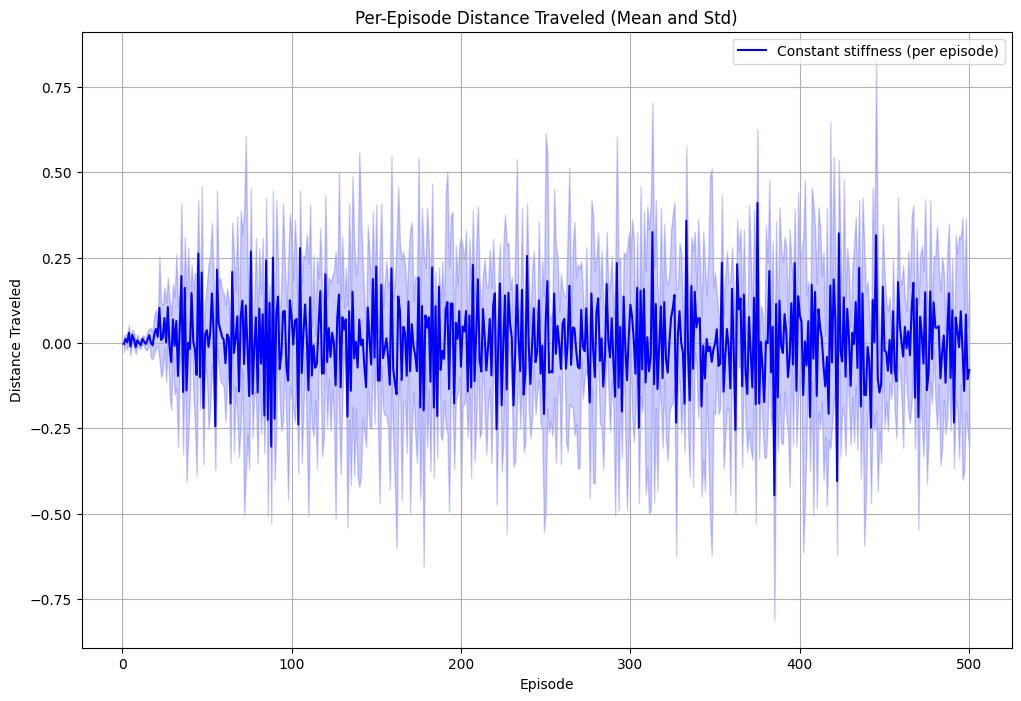

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# # Load data
# dist_file = [
#     fr'C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Aug01_constant_10k_lr_5e-04_PPO\displacements\displacements_seed_{seed_value}.npy'
#     for seed_value in range(100, 105)
# ]
group1_data = [np.load(file) for file in dist_file]

# Convert to array
group1_data = np.array(group1_data)

# Compute per-episode distance by taking the difference along axis=1
# This assumes the data is cumulative distance
group1_episodewise = np.diff(group1_data, axis=1)

# Compute mean and std
group1_mean = group1_episodewise.mean(axis=0)
group1_std = group1_episodewise.std(axis=0)

# Plotting
plt.figure(figsize=(12, 8))
episodes = np.arange(1, group1_mean.shape[0] + 1)

plt.plot(episodes, group1_mean, label="Constant stiffness (per episode)", color="blue")
plt.fill_between(episodes, group1_mean - group1_std, group1_mean + group1_std, color="blue", alpha=0.2)

plt.title("Per-Episode Distance Traveled (Mean and Std)")
plt.xlabel("Episode")
plt.ylabel("Distance Traveled")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# === CONFIGURATION ===
seed = 101  # change as needed

folder_name = rf"C:\Users\User\Desktop\Dynamic-tendon-Leg\{des}\stiffness\stiffness_seed_100.npy"
# file_path = os.path.join( folder_name, "tendon_forces", f"tendon_forces_seed_{seed}.npy")
file_path = folder_name
# === LOAD DATA ===
try:
    tendon_data = np.load(file_path, allow_pickle=True)
except FileNotFoundError:
    raise FileNotFoundError(f"Tendon force file not found at:\n{file_path}")

# === GET LAST EPISODE ===
if len(tendon_data) == 0:
    raise ValueError("No episode data found in tendon force file.")
print(tendon_data)
last_episode = tendon_data[-1][-100:]  # list of timesteps
num_timesteps = len(last_episode)
# print(last_episode)
# === ORGANIZE FORCE DATA ===
num_tendons = 3
active_forces = {i: [] for i in range(num_tendons)}
passive_forces = {i: [] for i in range(num_tendons)}

for timestep in last_episode:
    for entry in timestep:
        tid = entry['tendon_id']
        active_forces[tid].append(entry['active'])
        passive_forces[tid].append(entry['passive'])

# === PLOT ===
timesteps = np.arange(num_timesteps)
for tid in range(num_tendons):
    plt.figure(figsize=(10, 4))
    plt.plot(timesteps, active_forces[tid], label='Active Force')
    plt.plot(timesteps, passive_forces[tid], label='Passive Force')
    plt.title(f"Tendon {tid+1} – Active vs Passive Force (Last Episode)")
    plt.xlabel("Timestep")
    plt.ylabel("Force")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


[50]


IndexError: invalid index to scalar variable.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import cm

# des = 'Dynamic-tendon-Leg\JJ\data/LegEnv_Jul16_constant_5k_lr_5e-04_PPO_dt_0.001_fs_10'

episode =   500 #5/(0.005* 20)
# Load data (adjust paths if needed)
folder = rf"C:\Users\User\Desktop\Dynamic-tendon-Leg\{des}" #_reward_new"
seed = 101
force_path = fr'{folder}/actuator_forces/actuator_forces_seed_{seed}.npy'
qpos_path = fr'{folder}/kinematics/qpos_seed_{seed}.npy'


qpos_data = np.load(qpos_path, allow_pickle=True)
#last_qpos = np.array(qpos_data[-1])     # shape (T, dof)
# Convert object array of arrays to real 2D float array
last_qpos = np.array([np.array(x, dtype=np.float32) for x in qpos_data[-1]])
print( np.shape(last_qpos))
print(type(last_qpos))
print(type(last_qpos[0]))
print(last_qpos[0])


# Turn 1D array of arrays into 2D array
last_qpos = np.stack(last_qpos)
print( np.shape(last_qpos))
last_qpos=last_qpos[episode:]
# Downsample data
step = 1
hip_angles =np.degrees(last_qpos[::step, 1])
knee_angles = np.degrees(last_qpos[::step, 2])




# Create line segments from (hip, knee) points
points = np.array([hip_angles, knee_angles]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Normalize time for color mapping
time_steps = np.linspace(0, 1, len(segments))
colors = cm.plasma(time_steps)

# Create line collection for colored path
lc = LineCollection(segments, colors=colors, linewidth=2)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.add_collection(lc)
ax.set_xlim(-50, 80)
ax.set_ylim(-100, 20)
ax.set_xlabel("Hip Angle")
ax.set_ylabel("Knee Angle ")
ax.set_title(" Angle-Angle Plot: Hip vs Knee \n last 5s")

# Colorbar
mappable = cm.ScalarMappable(cmap='plasma')
mappable.set_array(time_steps)
fig.colorbar(mappable, ax=ax, label="Normalized Time")

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Dynamic-tendon-Leg\\Dynamic-tendon-Leg\\JJ\\data\\LegEnv_Jul23_constant_5k_lr_5e-04_PPO/kinematics/qpos_seed_101.npy'

(501, 1000, 3)


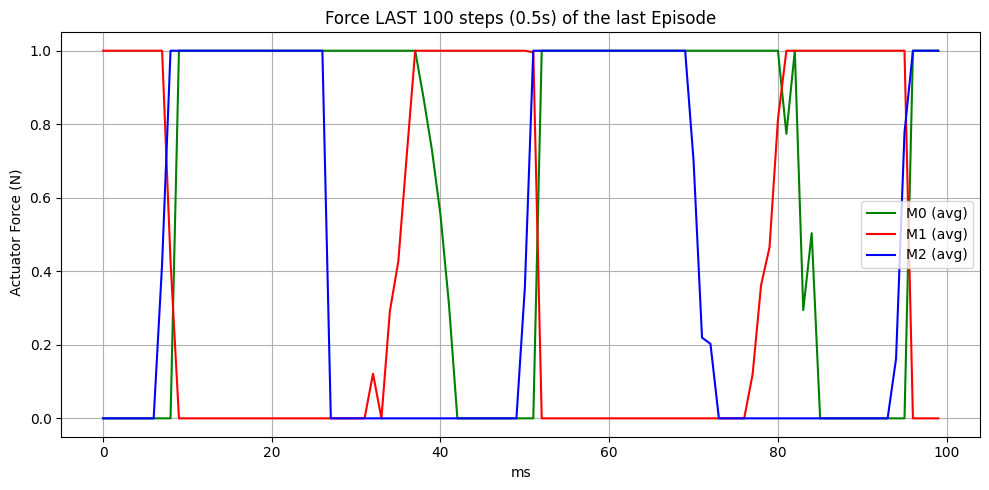

In [19]:
# Use only the last episode
import numpy as np
import matplotlib.pyplot as plt

# Load previously saved tendon forces
 #"C:\Users\User\Desktop\Dynamic-tendon-Leg\data\LegEnv_Jun06_constant_10k_constant_5e-04_PPO_seeds_100-100"
folder = rf"C:\Users\User\Desktop\Dynamic-tendon-Leg\Dynamic-tendon-Leg\Linear_Dynamic\data\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO"
seed = 101
force_path = fr'{folder}/actuator_forces/actuator_forces_seed_{seed}.npy'
episodes = np.load(force_path, allow_pickle=True)
print(np.shape(episodes))

last_episode = np.array(episodes[-1][900:])  # shape: (timesteps, 3)


# Plot
plt.figure(figsize=(10, 5))
plt.plot(last_episode[:, 0], label='M0 (avg)', color ="green")
plt.plot(last_episode[:, 1], label='M1 (avg)', color= "red")
plt.plot(last_episode[:, 2], label='M2 (avg)', color= "blue")

plt.xlabel("ms")
plt.ylabel(" Actuator Force (N)")
plt.title("Force LAST 100 steps (0.5s) of the last Episode")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


500


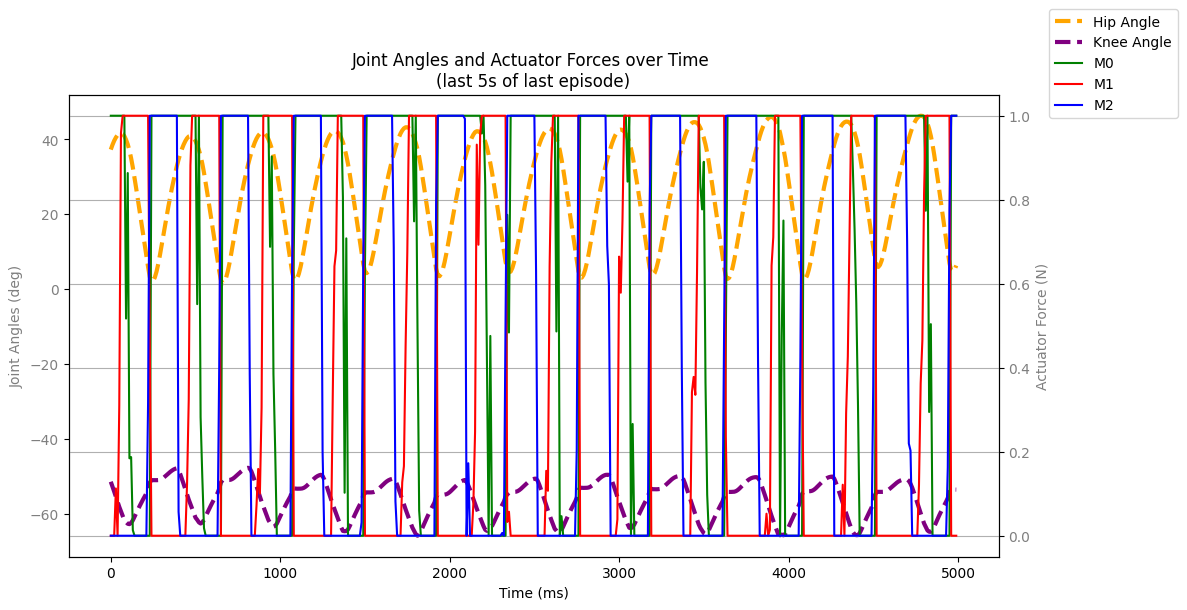

In [18]:
import numpy as np
import matplotlib.pyplot as plt
des = 'Dynamic-tendon-Leg\JJ\data/LegEnv_Jul16_constant_5k_lr_5e-04_PPO_dt_0.001_fs_10'
# Load data
folder = rf"C:\Users\User\Desktop\Dynamic-tendon-Leg\Dynamic-tendon-Leg\Linear_Dynamic\data\LegEnv_Aug01_seeds_100-110_linear_50-100_lr_5e-04_PPO"

seed = 101

episode = 500
dt = 1 / (0.001*10)
# Load kinematic data (angles)
qpos_path = fr'{folder}/kinematics/qpos_seed_{seed}.npy'
qpos_data = np.load(qpos_path, allow_pickle=True)
last_qpos = np.array([np.array(x, dtype=np.float32) for x in qpos_data[-1]])
last_qpos = np.stack(last_qpos)[episode:]  # Last 0.5s

# Load actuator force data
force_path = fr'{folder}/actuator_forces/actuator_forces_seed_{seed}.npy'
episodes = np.load(force_path, allow_pickle=True)
last_episode = np.array(episodes[-1][episode:])  # Last 0.5s

# Convert angles to degrees
hip_angles = np.degrees(last_qpos[:, 1])
knee_angles = np.degrees(last_qpos[:, 2])

# Time axis (assuming 1800Hz → 1/1800s per step)
print(len(hip_angles))
time = np.arange(len(hip_angles))*10 # in milliseconds

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Y1 axis: Joint Angles ---
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Joint Angles (deg)", color='tab:gray')
ax1.plot(time, hip_angles, label="Hip Angle", color='orange', linewidth = 3, linestyle='--')
ax1.plot(time, knee_angles, label="Knee Angle", color='purple', linewidth=3, linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:gray')

# Create second y-axis for forces
ax2 = ax1.twinx()
ax2.set_ylabel("Actuator Force (N)", color='tab:gray')
ax2.plot(time, last_episode[:, 0], label='M0', color='green', )
ax2.plot(time, last_episode[:, 1], label='M1', color='red')
ax2.plot(time, last_episode[:, 2], label='M2', color='blue',)
ax2.tick_params(axis='y', labelcolor='tab:gray')

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right",  bbox_to_anchor=(1.2, 1.2))

# Title and layout
plt.title("Joint Angles and Actuator Forces over Time \n(last 5s of last episode)")
plt.grid(True)
# plt.tight_layout()
plt.show()
